# 13 — Imitation

Behaviour cloning, DAgger, and what a student must be able to see ·
SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/13-imitation/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** MuJoCo renders through
    EGL on Colab, and that needs the GPU runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

It trains six small students on the CPU; the whole notebook takes a few
minutes.

## Learning from someone who already knows

Reinforcement learning discovers behaviour from a score, and weeks 8–12
showed what that costs: millions of steps, noise that destroys what it
explores, a reward that has to be exactly right.

If an **expert** already exists — a person with a joystick, a slow
planner, a hand-written controller — there is a shortcut: record what it
does and **copy it**. That is supervised learning, the easiest kind
there is.

We have three experts: the week-4 **walker**, the week-12 **policy**,
and the week-11 **planner**. We copy each one, and two of the three
copies fail. Why they fail is the lecture.

**Layer 5**: the half of modern robot learning that does not use
rewards.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import time, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import soc4180          # first: it selects the GL backend before mujoco loads
from pathlib import Path
from stable_baselines3 import PPO
from soc4180 import checkpoints, imitation as im
from soc4180.envs import G1PushEnv
from soc4180.walking import GaitParams
warnings.filterwarnings("ignore")
torch.set_num_threads(4)

walk_env, params = im._walker_env(), GaitParams(n_steps=40)
print(f"walker env: {1 / walk_env.control_dt:.0f} Hz, action scale {walk_env.action_scale} rad, "
      f"{walk_env.max_steps} decisions = 10 s")

walker env: 100 Hz, action scale 1.0 rad, 1000 decisions = 10 s

------------------------------------------------------------------------

## Behaviour cloning

1.  Let the expert act. At every step record the pair *(what the student
    will be shown, what the expert did)*.
2.  Fit a network to those pairs by squared error:
    $\min_\theta \sum_i \lVert \pi_\theta(o_i) - a_i^{\text{expert}} \rVert^2$
3.  Let the network act.

``` python
class Student(nn.Module):              # soc4180.imitation.Student
    # inputs standardised, two hidden layers of 256, ELU, 12 outputs
    @classmethod
    def fit(cls, X, Y, epochs=30):
        ...
        for _ in range(epochs):
            for b in batches:
                loss = ((s(X[b]) - Y[b]) ** 2).mean()
                opt.zero_grad(); loss.backward(); opt.step()
```

Step 2 is week 14’s `BallNet` training loop with a different $X$ and
$Y$. Nothing here needs a reward, a value function, or exploration. It
needs **examples** — and the question of *which* examples is the whole
subject.

------------------------------------------------------------------------

## Expert 1: the walker

The week-4 walker at 100 Hz, as `G1WalkEnv` actions — the setting at
which week 7 found it walks. Ten demonstrations, from ten slightly
different starting crouches:

In [2]:
SENSES = ["gravity", "gyro", "joints", "velocities"]
t0 = time.time()
demos = {}
for name, feats in (("sensors + clock + time", SENSES + ["clock", "time"]), ("clock + time", ["clock", "time"])):
    demos[name] = (feats, *im.walker_demos(10, feats, env=walk_env, params=params))
X = demos["clock + time"][1]
print(f"{len(X):,} examples from 10 demonstrations ({time.time() - t0:.0f} s); "
      f"each 10 s walk is 1000 decisions, the falls are shorter")

8,428 examples from 10 demonstrations (21 s); each 10 s walk is 1000 decisions, the falls are shorter

The walker is **open loop**: its action is a function of the *time*,
through the footstep plan and the LIPM, and of nothing it measures.
Three of the ten demonstrations fall (week 4 found the gait sensitive) —
they are examples too.

------------------------------------------------------------------------

## Two students

In [3]:
results = {}
for name, (feats, X, Y) in demos.items():
    s = im.Student.fit(X, Y, epochs=100)
    walks = im.walk(s, feats, env=walk_env, params=params)
    results[name] = (s.train_mse, walks)
    print(f"{name:24s} training MSE {s.train_mse:.1e}   walks: "
          + ", ".join(f"{x:+.2f} m" + (" (fell)" if n < 1000 else "") for n, x in walks))

sensors + clock + time   training MSE 9.0e-06   walks: -0.07 m (fell), -0.05 m (fell), -0.11 m (fell)
clock + time             training MSE 1.8e-05   walks: +1.15 m, +1.14 m, +1.15 m

The student that sees **more** — every sensor, plus the clock — fits the
expert **better** and falls over within three seconds, every time.

The student that sees only the clock fits it worse, and walks exactly as
far as the walker does.

------------------------------------------------------------------------

## More information, lower error, worse robot

Measured with `imitate.py`, 10 demonstrations, 100 epochs, three starts:

| student sees            | training MSE | walks                       |
|-------------------------|--------------|-----------------------------|
| time only (1 number)    | 9.0e-3       | stands still, never falls   |
| **clock + time**        | 1.8e-5       | **1.14–1.15 m, every time** |
| sensors + clock + time  | 9.0e-6       | falls after 2.3–2.6 s       |
| … + the previous action | 3e-6         | falls after 1.5–2.8 s       |

The training error goes **down** the table and the robot gets **worse**.
Nothing about the fitting is wrong. What is wrong is the question it
answered: *“predict the expert’s action on the expert’s states”* — and
the student does not stay on the expert’s states.

------------------------------------------------------------------------

## Covariate shift

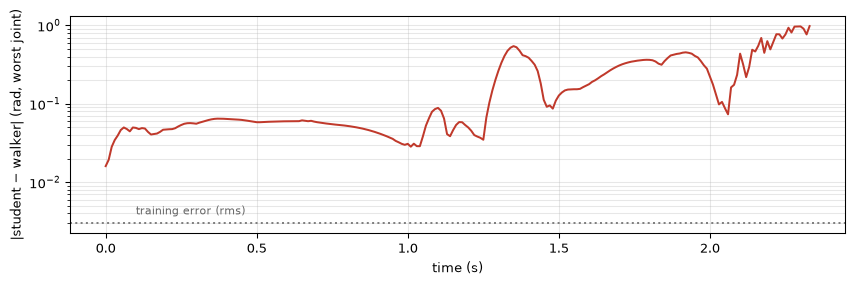

In [4]:
feats, Xs, Ys = demos["sensors + clock + time"]
s = im.Student.fit(Xs, Ys, epochs=100)
obs, _ = walk_env.reset(seed=100); gap = []
from soc4180.envs import walker_actions
from soc4180.walking import WalkingController
wc = WalkingController(walk_env.model, params)
while True:
    t = walk_env.data.time
    a_student = s.act(im.observe(obs, t, feats, params))
    a_expert = walker_actions(walk_env, wc, t)                # what the walker would do here
    gap.append((t, np.abs(a_student - a_expert).max()))
    obs, _, term, trunc, _ = walk_env.step(a_student)
    if term or trunc:
        break
gap = np.array(gap)
fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(gap[:, 0], gap[:, 1], color="#c0392b", lw=1.5)
ax.axhline(np.sqrt(s.train_mse), color="0.5", ls=":"); ax.text(0.1, np.sqrt(s.train_mse) * 1.3, "training error (rms)", fontsize=8, color="0.4")
ax.set_xlabel("time (s)"); ax.set_ylabel("|student − walker| (rad, worst joint)"); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); plt.show()

The sensor-student’s first action is already a few hundredths of a
radian off — ten times its training error, because its own starting
crouch was never demonstrated. Each error moves the robot to a state
**no demonstration visited**; there the network is guessing, the next
error is larger, and the states drift further. The gap grows until the
robot is on the floor. **Ross, Gordon & Bagnell, 2011**: behaviour
cloning’s error can grow with the *square* of the horizon.

------------------------------------------------------------------------

## Why the clock student survives

Its input is the time. The robot’s state — however wrong — never reaches
it, so there is nothing to drift away from: it replays the walker’s
commands exactly, like a **tape recorder**.

That is also its limit. It is the week-4 walker, including every
weakness the walker had: open loop, no feedback. A 40 N sideways shove
at t = 3 s knocks it over from every start
(`imitate.py --features clock time --push 40`); holding the crouch
survives 65. It learned the expert’s *actions*, and the expert’s actions
did not contain any knowledge of balance to learn.

> A student can only learn what the expert’s decision depended on, and
> only if it can see it.

The sensor-student could see the robot’s state, but the walker’s
decision never depended on it. So the network found **accidental**
correlations — on the expert’s trajectory, knee angle predicts the next
action very well — that mean nothing off it. *Causal confusion* (de Haan
et al., 2019); the previous action is the worst offender, because on a
smooth trajectory it predicts the next action almost perfectly.

------------------------------------------------------------------------

## Expert 2: a policy

Week 12’s PPO policy, trained on randomised worlds, **is** a function of
42 numbers — it is a network that reads them. Copy it from exactly
those:

In [5]:
BASE = "https://raw.githubusercontent.com/gnoejh/soc4180/main/weeks/12-robustness/checkpoints/"
local = Path("../12-robustness/checkpoints/push_random.zip")
teacher = PPO.load(local if local.exists() else checkpoints.download("push_random.zip", BASE + "push_random.zip"),
                   device="cpu")
push_env = G1PushEnv()
ALL = ["gravity", "gyro", "joints", "velocities", "previous"]
t0 = time.time()
Xp, Yp = im.policy_demos(push_env, teacher, 40, ALL)
copy = im.Student.fit(Xp, Yp)
print(f"40 demonstrations, {len(Xp):,} examples; training MSE {copy.train_mse:.1e} ({time.time() - t0:.0f} s)")
print(f"{'survived of 20, sideways shove':34s}" + "".join(f"{p:>6} N" for p in (80, 100)))
for name, pol, f in (("the policy itself", teacher, None), ("its student", copy, ALL)):
    print(f"{name:34s}" + "".join(f"{im.shove_test(push_env, pol, f, push=p):8d}" for p in (80, 100)))

40 demonstrations, 7,368 examples; training MSE 8.4e-05 (12 s)
survived of 20, sideways shove        80 N   100 N
the policy itself                       20      16
its student                             20      12

------------------------------------------------------------------------

## When copying works

The student learns in **seconds** from 40 demonstrations what PPO needed
3 million steps to find, and it is nearly as good: every shove at 80 N,
most of them at 100.

Three things made it work, and each was missing for the walker:

1.  The expert’s action **is a function of what the student sees** —
    exactly.
2.  The expert is **deterministic**: the same state always gets the same
    answer, so there is one thing to fit, not an average of several.
3.  The expert is **closed loop**: its demonstrations include recoveries
    from the small wobbles every episode has, so the data is not a
    single thin line through state space.

This is the recipe behind most robot learning you have heard of —
**distillation**: train something expensive (an RL policy with
privileged information, a planner, a person), then copy it into
something cheap.

------------------------------------------------------------------------

## Take a sensor away

The real G1’s joint velocities come from differentiating encoder counts
and are noisy. Suppose the student may not use them — 30 numbers instead
of 42. The expert still uses all 42.

Measured with
`imitate.py --expert policy --features gravity gyro joints previous`
(100 N sideways, 20 episodes; the policy itself: 16):

| student                         | behaviour cloning | \+ 3 rounds of DAgger |
|---------------------------------|-------------------|-----------------------|
| all 42 numbers                  | 12                | —                     |
| no velocities, now only         | **0**             | 7                     |
| no velocities, **last 5 steps** | 3                 | **16**                |

With the velocities gone the expert’s decision depends on something the
student cannot see, and more data helps only a little (DAgger: 0 → 7).
Give it the last five steps of joint angles and it *can* see velocity
again — as a difference between steps — but only once DAgger shows it
the states its own mistakes lead to.

------------------------------------------------------------------------

## DAgger

**Dataset Aggregation** (Ross, Gordon & Bagnell, 2011) fixes covariate
shift by collecting data where the *student* goes:

``` python
student = Student.fit(X, Y)                      # 1. behaviour cloning
for round in range(3):
    for episode in range(20):
        run the STUDENT (round 1: half the steps the teacher's, so it lasts)
        at every state it visits, record (what it saw, what the TEACHER would do)
    X, Y = X + new, Y + new                        # 2. the dataset only grows
    student = Student.fit(X, Y)                    # 3. retrain on everything
```

It needs an expert that can be **asked** — “what would you do *here*?” —
at any state, not just one that can perform. A recorded human
demonstration cannot be asked. A policy can. A planner can, at a price.

------------------------------------------------------------------------

## Expert 3: the planner

Week 11’s MPPI can be asked about any state — it just plans from there.
It survives 300 N. Copy it:

| episodes of 20 survived       | 60 N  | 80 N | 100 N | 120 N |
|-------------------------------|-------|------|-------|-------|
| its student, 8 demonstrations | **0** | 0    | 0     | 0     |
| hold the crouch               | 20    | 0    | 0     | 0     |

Measured with `imitate.py --expert planner` (MPPI itself stood through
150 and 300 N in week 11). Training MSE 1.1e-2 — a hundred times the
policy student’s — and a student that falls at 60 N, where doing nothing
at all survives. DAgger rounds, with MPPI labelling the student’s own
states, do not rescue it: after `--dagger 3` the student survives 2 of
20 at 60 N, and its training error *rises* each round (1.1e-2 → 2.0e-2)
— the more states it is shown, the less consistent the labels become.

------------------------------------------------------------------------

## Why the planner cannot be copied

Check it against the three conditions:

1.  **Not a function of what the student sees.** MPPI plans from the
    full simulator state — pelvis velocity, the centre of mass, contact
    — and from its own previous plan $U$, which it keeps between
    decisions. Two identical observations can get two different answers.
2.  **Not deterministic.** Each decision averages 64 random futures; ask
    twice, get two answers. The labels are noisy.
3.  **Not unimodal.** Step left or step right can both be good. Squared
    error averages them — into standing still.

Distilling planners is done — Guided Policy Search (Levine & Koltun,
2013), and the planners inside AlphaZero and TD-MPC2 are trained
*together with* the networks that copy them, so that the planner’s
answers stay consistent enough to learn. An off-the-shelf MPPI is not.

------------------------------------------------------------------------

## Teacher and student, in production

The legged-robot recipe since 2020 (Lee et al., ANYmal; Kumar et al.,
RMA):

1.  Train a **teacher** with RL in simulation, and let it observe
    **privileged** information — terrain, friction, its true velocity,
    the push. It learns fast because it can see everything.
2.  Distill it with **DAgger** into a **student** that sees only what
    the real robot has — IMU, joint encoders — plus a **history** of
    them, from which it must *infer* what the teacher was told.
3.  Deploy the student.

Every piece of it is in today’s lecture: distillation, DAgger, a history
standing in for a missing sensor. Week 12’s `robust.py --privileged`
trains such a teacher; making it better than the policy it is compared
with is exercise 5.

------------------------------------------------------------------------

## Where imitation is going

The expert does not have to be a program:

- **Teleoperation**: a person drives the robot (ALOHA, 2023 — two arms,
  a few dozen demonstrations per task). Humans are multimodal experts,
  so students predict *distributions* — action chunks, diffusion
  policies — instead of a single mean action.
- **Video of people**: no actions recorded at all; they must be
  inferred.
- **The internet**: vision-language-action models (RT-2, OpenVLA, π0)
  are behaviour cloning on hundreds of thousands of robot episodes,
  starting from a network pretrained on images and text. That is week
  15.

All of them are behaviour cloning. All of them face today’s two
questions: *which states do the examples cover*, and *can the student
see what the expert’s decision depended on*.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/13-imitation/lab_imitate.py      # torch + SB3: uv sync --extra rl
```

A game with four students to train. **You edit only `students.py`**:
what each student is shown, how much history, how many demonstrations,
how many rounds of DAgger. `1`–`4` train and test a student (the window
freezes while it trains, then the test plays at 5×), `G` grades all
four.

| \# | Problem | What it teaches |
|------------------------|------------------------|------------------------|
| 1 | TAPE: copy the walker, walk 1 m | the student must see what the expert used — and nothing misleading |
| 2 | COPY: copy the policy, 100 N | when copying works |
| 3 | FEW: at most 2 demonstrations | DAgger buys back data: cloning 0/20, + 2 rounds 20/20 |
| 4 | BLIND: no joint velocities | history stands in for a missing sensor |

------------------------------------------------------------------------

## Lab class: `imitate.py`

``` bash
uv run weeks/13-imitation/imitate.py
uv run weeks/13-imitation/imitate.py --features clock time
uv run weeks/13-imitation/imitate.py --expert policy
uv run weeks/13-imitation/imitate.py --expert policy --features gravity gyro joints previous --history 5 --dagger 3
uv run weeks/13-imitation/imitate.py --expert planner
```

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | the expert | `WalkingController` + `walker_actions`; `PPO.load`; `planning.MPPI` |
| 2 | demonstrations | `imitation.walker_demos`, `policy_demos`, `observe` |
| 3 | cloning, DAgger | `Student.fit`, `imitation.dagger` |
| 4 | the job | `imitation.walk`, `shove_test` (`xfrc_applied` via `push_force`) |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Noise injection (DART).** Record the walker while adding small
    random noise to the actions it *executes* (label with the clean
    action). Does the sensor-student last longer? Does it ever walk?
2.  **How many demonstrations?** Plot the COPY student’s survival at 100
    N against 5, 10, 20, 40, 80 demonstrations, with and without DAgger.
3.  **Which sensor matters?** Remove each feature group in turn from the
    COPY student. Which removal hurts most? Which does not matter at
    all?
4.  **History length.** For BLIND, try 2, 3, 5, 10 steps. Where does it
    stop helping?
5.  **A better teacher.** Train `robust.py --privileged` longer, or with
    a larger network, until it beats `push_random` at 100 N; then
    distill it into a BLIND student.
6.  **Average of two modes.** Record MPPI’s action twice at the same
    state (reset its plan in between). How different are the two
    answers?

------------------------------------------------------------------------

## Next week

**14 — Learning from pixels.** Every student today read numbers from the
robot’s own body. Next week the robot gets a camera, and the student’s
input becomes 12,288 pixels — with labels the simulator hands us for
free, and a failure the moment the world changes colour.